In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Normalize
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_set = MNIST("./MNIST_dataset", train=True, download=True, transform=Compose([ToTensor(), Normalize((0.1307,), (0.3081,))]))
test_set = MNIST("./MNIST_dataset", train=False, download=True, transform=Compose([ToTensor(), Normalize((0.1307, ),(0.3081, ))]))

In [3]:
epochs = 50
batch_size = 128
criterion = nn.CrossEntropyLoss()
alpha = 1e-4

In [4]:
train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4) 
test_loader = DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

In [5]:
data_visual, target_visual = next(iter(train_loader))
print(f"The values of data visualized: {data_visual}, and \n the values of target visualized: {target_visual}")
print(f"The shape of data: {data_visual.shape} and the shape of target: {target_visual.shape}")

The values of data visualized: tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.42

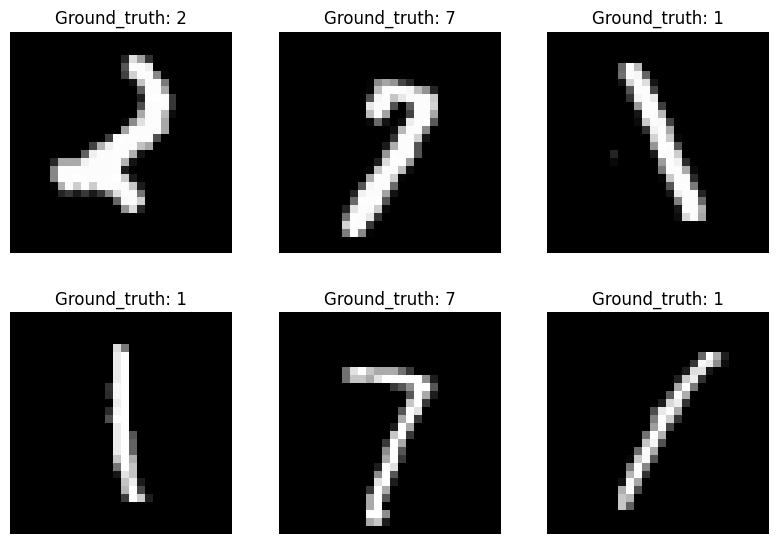

In [6]:
fig = plt.figure(figsize=(8, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.title("Ground_truth: {}".format(target_visual[i]))
    plt.tight_layout()
    plt.imshow(data_visual[i][0], cmap='gray')
    plt.axis("off")
    
plt.show(fig)


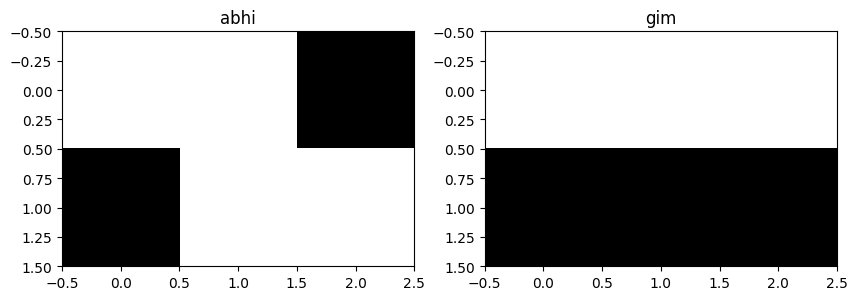

In [7]:
name = ["abhi", "gim", "gemma"]

fig = plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.title("{0}".format(name[0]))
plt.imshow(np.array([[0, 0, 1],
                     [1, 0, 0]]), cmap="binary")
plt.subplot(1, 2, 2)
plt.title("{0}".format(name[1]))
plt.imshow(np.array([[0, 0, 0],
                     [1, 1, 1]]), cmap="binary")

In [8]:
class Classifer(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=in_channel, out_channels=8, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=8, out_channels=32, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(in_features=32*4*4, out_features=64),
            nn.Tanh(),
            nn.Dropout(),
            
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Dropout(),
            
            nn.Linear(32, out_channel)
        )
        
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.shape[0], -1) # similar to x.view(x.size(0), -1) or nn.Flatten() basically used for keeping B from B, C, H, W
        x = self.classifier(x)
        return F.softmax(x, dim=1)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
model = Classifer(in_channel=1, out_channel=10).to(device)

In [11]:
model = nn.DataParallel(model)

In [12]:
data_visual.view(-1, 28).shape

torch.Size([3584, 28])

In [13]:
x = torch.randn(16, 32, 4, 4)
x.shape

torch.Size([16, 32, 4, 4])

In [14]:
x.view(x.shape[0], -1).shape

torch.Size([16, 512])

In [15]:
optimizer = optim.Adam(params=model.parameters(), lr=alpha)

In [16]:
for epoch in range(epochs):
    total_loss = 0
    for idx, data in enumerate(train_loader):
        X, y = data
        X = X.to(device)
        y = y.to(device)
        
        # Forward pass
        y_pred = model(X)        
        
        loss = criterion(y_pred, y)
        total_loss += loss
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # update
        
        optimizer.step()
        
    print(f"Loss: {total_loss/len(train_loader)}, for epoch {epoch+1}/{epochs} ")

Loss: 2.14162540435791, for epoch 1/50 
Loss: 1.886765718460083, for epoch 2/50 
Loss: 1.7465829849243164, for epoch 3/50 
Loss: 1.6590970754623413, for epoch 4/50 
Loss: 1.6102908849716187, for epoch 5/50 
Loss: 1.581181526184082, for epoch 6/50 
Loss: 1.5620118379592896, for epoch 7/50 
Loss: 1.5479869842529297, for epoch 8/50 
Loss: 1.5383769273757935, for epoch 9/50 
Loss: 1.5310008525848389, for epoch 10/50 
Loss: 1.5246690511703491, for epoch 11/50 
Loss: 1.5198109149932861, for epoch 12/50 
Loss: 1.5162279605865479, for epoch 13/50 
Loss: 1.5124764442443848, for epoch 14/50 
Loss: 1.5094090700149536, for epoch 15/50 
Loss: 1.5067274570465088, for epoch 16/50 
Loss: 1.50406813621521, for epoch 17/50 
Loss: 1.502069115638733, for epoch 18/50 
Loss: 1.5005607604980469, for epoch 19/50 
Loss: 1.4993647336959839, for epoch 20/50 
Loss: 1.4982082843780518, for epoch 21/50 
Loss: 1.4962878227233887, for epoch 22/50 
Loss: 1.4956212043762207, for epoch 23/50 
Loss: 1.4951351881027222, f

In [17]:
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor,"\t", model.state_dict()[param_tensor].size())

Model's state_dict:
module.conv_block.0.weight 	 torch.Size([8, 1, 5, 5])
module.conv_block.0.bias 	 torch.Size([8])
module.conv_block.3.weight 	 torch.Size([32, 8, 5, 5])
module.conv_block.3.bias 	 torch.Size([32])
module.classifier.0.weight 	 torch.Size([64, 512])
module.classifier.0.bias 	 torch.Size([64])
module.classifier.3.weight 	 torch.Size([32, 64])
module.classifier.3.bias 	 torch.Size([32])
module.classifier.6.weight 	 torch.Size([10, 32])
module.classifier.6.bias 	 torch.Size([10])


In [18]:
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Optimizer's state_dict:
state 	 {0: {'step': tensor(23450.), 'exp_avg': tensor([[[[-9.6475e-03, -7.8010e-03, -4.1583e-03, -1.2680e-03,  2.6360e-03],
          [-1.0030e-02, -7.0446e-03, -2.3093e-03,  1.2366e-04,  3.2500e-03],
          [-8.3283e-03, -4.2480e-03, -6.2161e-04,  7.9451e-04,  4.2192e-03],
          [-4.8991e-03, -2.1169e-03,  5.4303e-04,  2.2685e-03,  5.6110e-03],
          [-2.7422e-03, -2.8048e-04,  6.0950e-04,  1.7283e-03,  5.2898e-03]]],


        [[[-2.1202e-03, -1.0609e-03,  1.2441e-04,  6.1179e-04,  9.6034e-04],
          [-1.6313e-03,  5.4023e-05,  4.7708e-04,  5.5384e-04,  6.5917e-04],
          [-2.4078e-05,  8.9532e-04,  4.0326e-04,  4.8252e-04, -3.0043e-04],
          [ 1.6791e-03,  1.0745e-03, -3.4901e-05, -1.2080e-04, -1.4718e-03],
          [ 1.4645e-03,  9.5250e-04, -2.7349e-04, -1.2455e-03, -1.1806e-03]]],


        [[[-2.3289e-03, -1.4346e-03, -1.3663e-03, -1.5547e-03, -3.2740e-03],
          [-2.1248e-03, -1.2968e-03, -2.7145e-03, -3.7926e-03, -4.3245e-0

In [19]:
torch.save(model.state_dict(), "/kaggle/working/model.pth")

In [20]:
model.eval()
test_loss, correct, total_corr = 0, 0, 0
with torch.no_grad():
    for idx, data in enumerate(test_loader):
        X, y = data
        X = X.to(device)
        y = y.to(device)
        
        y_pred_val = model(X)
        loss_pred = criterion(y_pred_val, y)
        
        correct = (y_pred_val.argmax(1) == y).sum()
        total_corr += correct
        test_loss += loss_pred
        
        print(f"accuracy: {correct/batch_size * 100}")
    
    print(f"Loss: {test_loss/len(test_loader)}, Total accuracy: {total_corr/len(test_loader.dataset)*100}")

accuracy: 100.0
accuracy: 99.21875
accuracy: 98.4375
accuracy: 97.65625
accuracy: 99.21875
accuracy: 97.65625
accuracy: 100.0
accuracy: 97.65625
accuracy: 98.4375
accuracy: 96.09375
accuracy: 97.65625
accuracy: 99.21875
accuracy: 98.4375
accuracy: 96.875
accuracy: 98.4375
accuracy: 98.4375
accuracy: 96.09375
accuracy: 97.65625
accuracy: 98.4375
accuracy: 98.4375
accuracy: 97.65625
accuracy: 99.21875
accuracy: 96.875
accuracy: 96.875
accuracy: 99.21875
accuracy: 98.4375
accuracy: 99.21875
accuracy: 96.875
accuracy: 99.21875
accuracy: 96.09375
accuracy: 96.875
accuracy: 96.875
accuracy: 98.4375
accuracy: 98.4375
accuracy: 99.21875
accuracy: 97.65625
accuracy: 98.4375
accuracy: 96.875
accuracy: 97.65625
accuracy: 100.0
accuracy: 100.0
accuracy: 100.0
accuracy: 100.0
accuracy: 100.0
accuracy: 98.4375
accuracy: 100.0
accuracy: 96.875
accuracy: 99.21875
accuracy: 98.4375
accuracy: 100.0
accuracy: 99.21875
accuracy: 95.3125
accuracy: 99.21875
accuracy: 100.0
accuracy: 100.0
accuracy: 100.0
ac

In [28]:
X[0].cpu().squeeze().shape

torch.Size([28, 28])

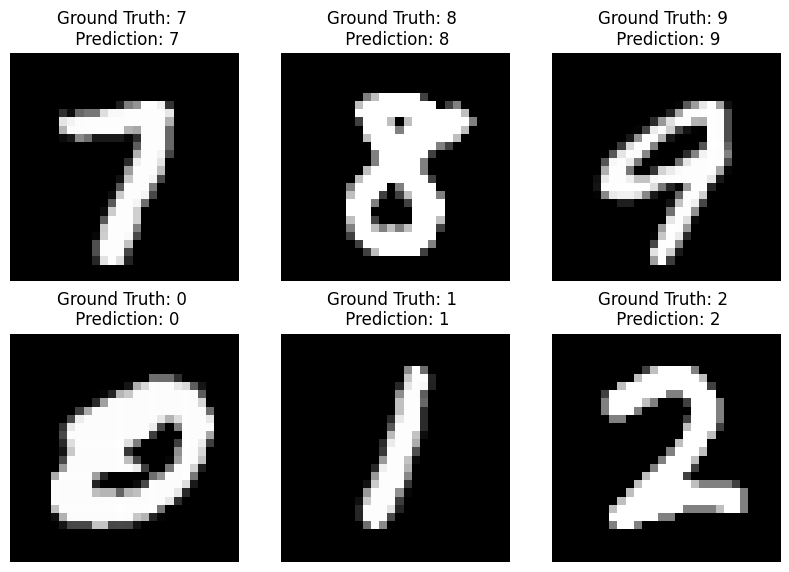

In [44]:
fig = plt.figure(figsize=(8, 6))

for i in range(6, 12, 1):
    plt.subplot(2, 3, (i-6)+1)
    plt.imshow(X[i].squeeze().cpu(), cmap="gray")
    plt.title(f"Ground Truth: {y[i]} \n Prediction: {y_pred_val[i].argmax()}")
    plt.tight_layout()
    plt.axis("off")

plt.show()